# Student Performance Prediction

This notebook performs machine learning analysis on student performance data.

Steps included in this project:

1. Import libraries
2. Load dataset
3. Explore dataset
4. Feature engineering
5. Data preprocessing
6. Model training
7. Model evaluation

## Step 1: Importing Required Libraries

In this step we import the necessary Python libraries required for data analysis, visualization, and machine learning.

Libraries used:

- pandas → data manipulation
- numpy → numerical operations
- matplotlib → data visualization
- seaborn → statistical visualization

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Step 2: Loading the Dataset

The dataset is loaded using pandas to begin analysis of student performance data.

In [2]:
df = pd.read_csv("../data/StudentsPerformance.csv")
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


## Step 3: Understanding the Dataset

Before applying machine learning models, it is important to explore the dataset.

In this step we check:

- dataset shape
- column names
- data types
- statistical summary
- missing values

In [3]:
df.shape

(1000, 8)

In [4]:
df.columns

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [6]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [7]:
df.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

## Step 4: Feature Engineering

Feature engineering helps create meaningful features from the dataset.

In this step:

- average_score is calculated using math, reading, and writing scores
- result column is created to classify students as pass or fail

In [8]:
df["average_score"] = (df["math score"] + df["reading score"] + df["writing score"]) / 3

In [9]:
df["result"] = df["average_score"].apply(lambda x: 1 if x >= 50 else 0)

In [10]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,average_score,result
0,female,group B,bachelor's degree,standard,none,72,72,74,72.666667,1
1,female,group C,some college,standard,completed,69,90,88,82.333333,1
2,female,group B,master's degree,standard,none,90,95,93,92.666667,1
3,male,group A,associate's degree,free/reduced,none,47,57,44,49.333333,0
4,male,group C,some college,standard,none,76,78,75,76.333333,1


## Step 5: Encoding Categorical Features

Machine learning models require numerical input.

In this step categorical features such as gender, lunch type, and parental education are converted into numeric format using Label Encoding.

In [11]:
from sklearn.preprocessing import LabelEncoder

In [12]:
le = LabelEncoder()

for col in df.select_dtypes(include="object").columns:
    df[col] = le.fit_transform(df[col])

In [13]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,average_score,result
0,0,1,1,1,1,72,72,74,72.666667,1
1,0,2,4,1,0,69,90,88,82.333333,1
2,0,1,3,1,1,90,95,93,92.666667,1
3,1,0,0,0,1,47,57,44,49.333333,0
4,1,2,4,1,1,76,78,75,76.333333,1


## Step 6: Exploratory Data Analysis

Exploratory Data Analysis (EDA) helps us understand patterns and relationships in the dataset.

In this step we visualize:

- distribution of average scores
- relationship between gender and performance
- correlation between features

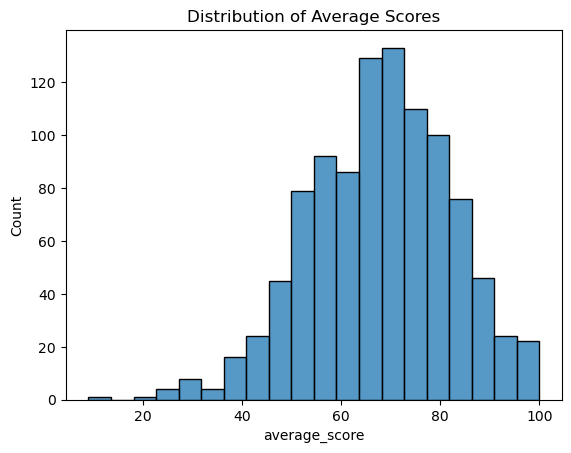

In [14]:
sns.histplot(df["average_score"], bins=20)
plt.title("Distribution of Average Scores")
plt.show()

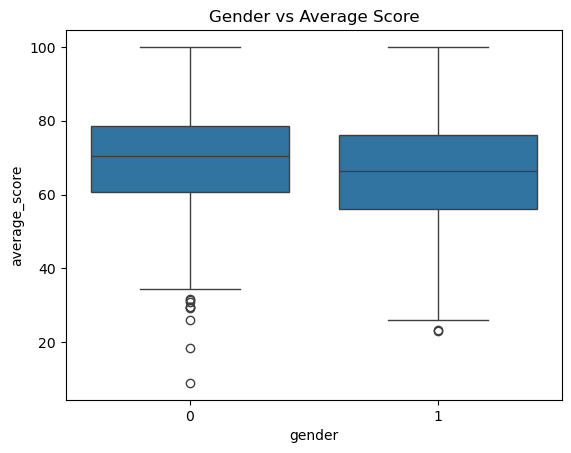

In [15]:
sns.boxplot(x="gender", y="average_score", data=df)
plt.title("Gender vs Average Score")
plt.show()

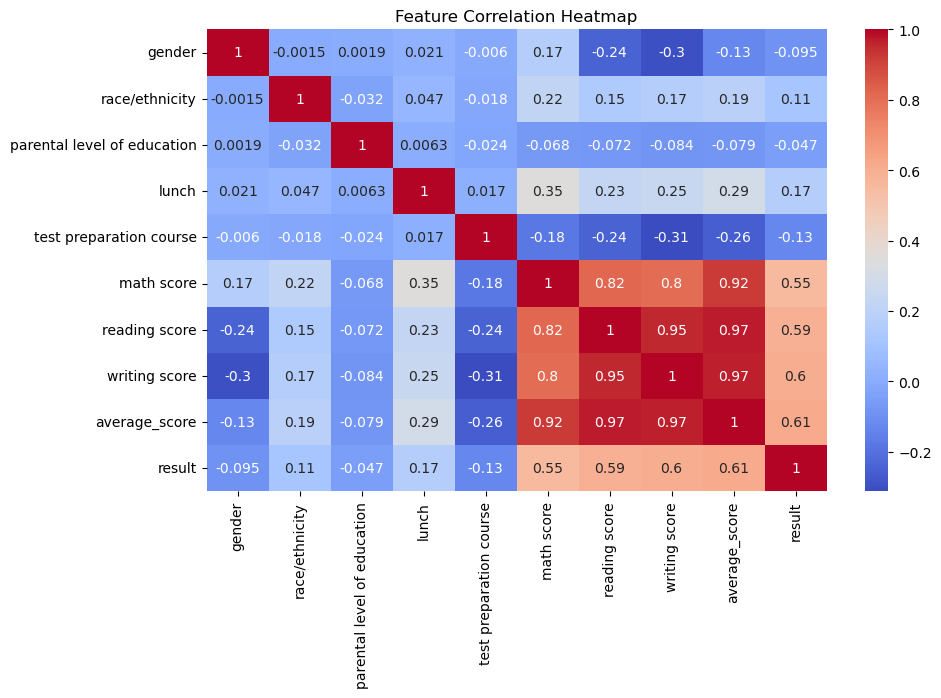

In [16]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

## Step 7: Train Test Split

The dataset is divided into training and testing sets.

- Training data → used to train the model
- Testing data → used to evaluate model performance

In [19]:
from sklearn.model_selection import train_test_split

X = df.drop("result", axis=1)
y = df["result"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape)
print(X_test.shape)

(800, 9)
(200, 9)


## Step 8: Logistic Regression Model

Logistic Regression is used as a baseline classification model to predict student performance.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

accuracy_lr = accuracy_score(y_test, y_pred_lr)

print("Logistic Regression Accuracy:", accuracy_lr)